# Torre de Hanoi
**Grupo 3 - Inteligencia Artificial USFQ**

Integrantes: Lucy Barreno, Ana Haro, Darwin Simba, Jhon Del Castillo

## ¿Qué es la Torre de Hanoi?

La **Torre de Hanoi** es un problema clásico de la matemática y la informática que consiste en mover una pila de discos de una torre a otra siguiendo tres reglas simples:

1. Solo se puede mover **un disco a la vez**
2. Solo se puede mover el disco que está en la **parte superior** de una pila
3. **No se puede colocar un disco más grande encima de uno más pequeño**

### Representación del problema
El problema se representa como un **árbol de estados**, donde:
- Cada **nodo** es un estado del sistema (configuración de los discos en las torres)
- Cada **arista** es un movimiento válido de un disco
- La solución es el **camino** desde el estado inicial hasta el estado final

### Complejidad
La solución óptima requiere exactamente **2ⁿ - 1 movimientos**, donde n es el número de discos:
- 3 discos → 7 movimientos
- 4 discos → 15 movimientos
- 10 discos → 1,023 movimientos
- 64 discos → 18,446,744,073,709,551,615 movimientos 😱

## Algoritmo: Recursión

La Torre de Hanoi tiene una solución elegante usando **recursión**:
1. Mover los **n-1 discos superiores** de la torre origen a la torre auxiliar
2. Mover el **disco más grande** de la torre origen a la torre destino
3. Mover los **n-1 discos** de la torre auxiliar a la torre destino

Este enfoque divide el problema en subproblemas más pequeños del mismo tipo (**divide y vencerás**).

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Algoritmo recursivo de Hanoi ──────────────────────────────────
movimientos = []

def hanoi(n, origen, destino, auxiliar):
    if n == 1:
        movimientos.append((n, origen, destino))
        return
    hanoi(n - 1, origen, auxiliar, destino)
    movimientos.append((n, origen, destino))
    hanoi(n - 1, auxiliar, destino, origen)

# Resolver para 3 discos
N_DISCOS = 3
movimientos = []
hanoi(N_DISCOS, 'A', 'C', 'B')

print(f"Torre de Hanoi con {N_DISCOS} discos")
print(f"Total de movimientos: {len(movimientos)} (óptimo: 2^{N_DISCOS}-1 = {2**N_DISCOS - 1})")
print()
print("Secuencia de movimientos:")
for i, (disco, origen, destino) in enumerate(movimientos, 1):
    print(f"  Paso {i:2d}: Disco {disco} → Torre {origen} a Torre {destino}")

Torre de Hanoi con 3 discos
Total de movimientos: 7 (óptimo: 2^3-1 = 7)

Secuencia de movimientos:
  Paso  1: Disco 1 → Torre A a Torre C
  Paso  2: Disco 2 → Torre A a Torre B
  Paso  3: Disco 1 → Torre C a Torre B
  Paso  4: Disco 3 → Torre A a Torre C
  Paso  5: Disco 1 → Torre B a Torre A
  Paso  6: Disco 2 → Torre B a Torre C
  Paso  7: Disco 1 → Torre A a Torre C


## Visualización 1: Estados de las Torres

Se muestran los estados clave de las torres durante la solución: el estado inicial, estados intermedios y el estado final.

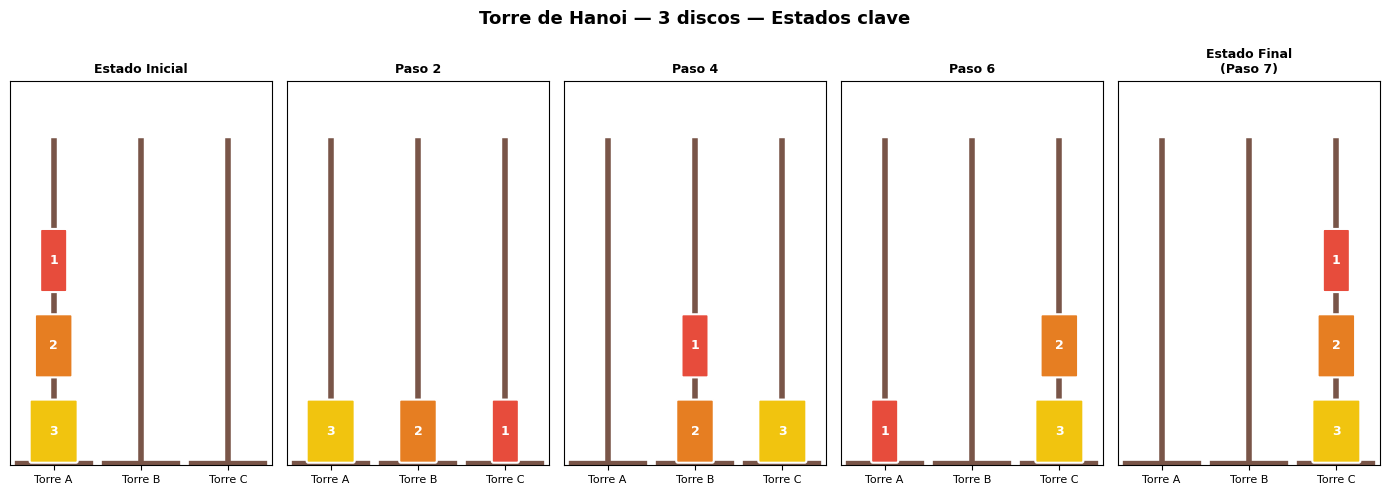

In [2]:
COLORES = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']

def simular_estados(n, movimientos):
    """Simula todos los estados de las torres paso a paso."""
    torres = {
        'A': list(range(n, 0, -1)),
        'B': [],
        'C': []
    }
    estados = [{'A': list(torres['A']), 'B': list(torres['B']), 'C': list(torres['C'])}]
    for disco, origen, destino in movimientos:
        torres[destino].append(torres[origen].pop())
        estados.append({'A': list(torres['A']), 'B': list(torres['B']), 'C': list(torres['C'])})
    return estados

def dibujar_torres(ax, estado, titulo, n):
    """Dibuja el estado de las tres torres."""
    ax.set_xlim(0, 3)
    ax.set_ylim(0, n + 1.5)
    ax.set_title(titulo, fontsize=9, fontweight='bold')
    ax.set_xticks([0.5, 1.5, 2.5])
    ax.set_xticklabels(['Torre A', 'Torre B', 'Torre C'], fontsize=8)
    ax.set_yticks([])
    ax.grid(False)

    # Dibujar postes
    for x in [0.5, 1.5, 2.5]:
        ax.plot([x, x], [0, n + 0.8], color='#795548', linewidth=4, zorder=1)
        ax.plot([x - 0.4, x + 0.4], [0, 0], color='#795548', linewidth=6, zorder=1)

    # Dibujar discos
    for col_idx, torre in enumerate(['A', 'B', 'C']):
        for fila, disco in enumerate(estado[torre]):
            ancho = 0.15 + disco * 0.12
            x_centro = 0.5 + col_idx
            rect = mpatches.FancyBboxPatch(
                (x_centro - ancho / 2, fila + 0.05),
                ancho, 0.7,
                boxstyle="round,pad=0.02",
                facecolor=COLORES[disco - 1],
                edgecolor='white', linewidth=1.5, zorder=2
            )
            ax.add_patch(rect)
            ax.text(x_centro, fila + 0.4, str(disco),
                    ha='center', va='center', fontsize=9,
                    fontweight='bold', color='white', zorder=3)

# Simular todos los estados
estados = simular_estados(N_DISCOS, movimientos)
total = len(estados)

# Mostrar estado inicial, pasos intermedios y final
indices_mostrar = [0, total // 4, total // 2, 3 * total // 4, total - 1]
indices_mostrar = sorted(set(indices_mostrar))

fig, axes = plt.subplots(1, len(indices_mostrar), figsize=(14, 5))
for ax, idx in zip(axes, indices_mostrar):
    if idx == 0:
        titulo = 'Estado Inicial'
    elif idx == total - 1:
        titulo = f'Estado Final\n(Paso {idx})'
    else:
        titulo = f'Paso {idx}'
    dibujar_torres(ax, estados[idx], titulo, N_DISCOS)

plt.suptitle(f'Torre de Hanoi — {N_DISCOS} discos — Estados clave', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Visualización 2: Evolución de discos por torre

El gráfico muestra cómo cambia la cantidad de discos en cada torre a lo largo de todos los pasos de la solución.

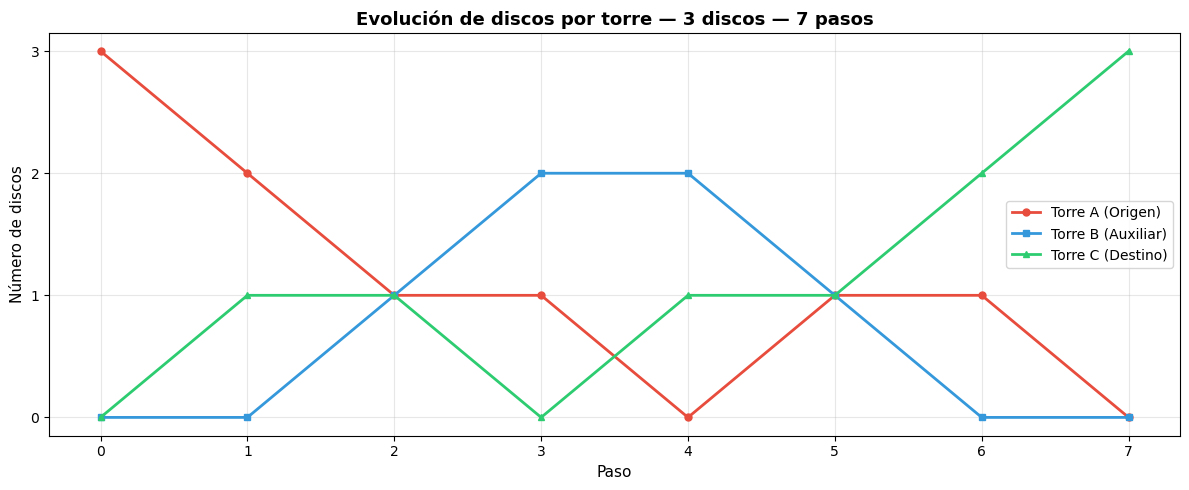

In [3]:
# Cantidad de discos por torre en cada paso
pasos = list(range(len(estados)))
cant_A = [len(e['A']) for e in estados]
cant_B = [len(e['B']) for e in estados]
cant_C = [len(e['C']) for e in estados]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pasos, cant_A, 'o-', color='#e74c3c', label='Torre A (Origen)', linewidth=2, markersize=5)
ax.plot(pasos, cant_B, 's-', color='#3498db', label='Torre B (Auxiliar)', linewidth=2, markersize=5)
ax.plot(pasos, cant_C, '^-', color='#2ecc71', label='Torre C (Destino)', linewidth=2, markersize=5)

ax.set_xlabel('Paso', fontsize=11)
ax.set_ylabel('Número de discos', fontsize=11)
ax.set_title(f'Evolución de discos por torre — {N_DISCOS} discos — {len(movimientos)} pasos', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_yticks(range(N_DISCOS + 1))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Visualización 3: Comparación de movimientos según número de discos

Muestra el crecimiento exponencial del número de movimientos necesarios al aumentar el número de discos. Esto ilustra por qué el problema es computacionalmente intenso.

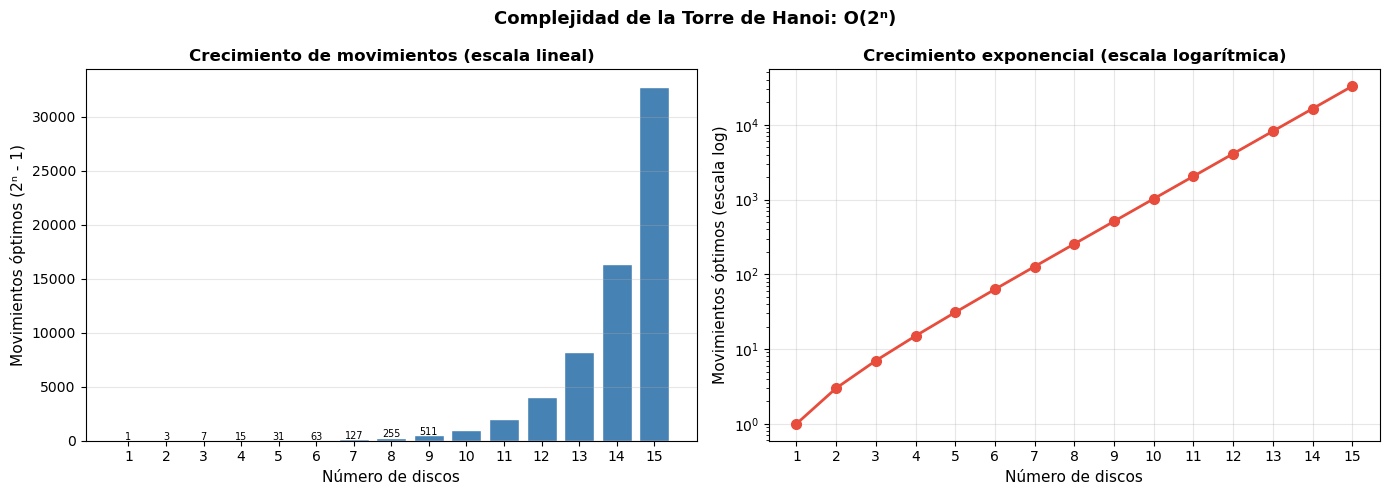

Tabla de movimientos por número de discos:
  Discos     Movimientos
-------------------------
       1               1
       2               3
       3               7
       4              15
       5              31
       6              63
       7             127
       8             255
       9             511
      10           1,023
      11           2,047
      12           4,095
      13           8,191
      14          16,383
      15          32,767


In [4]:
discos_rango = list(range(1, 16))
movs_optimos = [2**n - 1 for n in discos_rango]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala lineal
axes[0].bar(discos_rango, movs_optimos, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Número de discos', fontsize=11)
axes[0].set_ylabel('Movimientos óptimos (2ⁿ - 1)', fontsize=11)
axes[0].set_title('Crecimiento de movimientos (escala lineal)', fontsize=12, fontweight='bold')
axes[0].set_xticks(discos_rango)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(movs_optimos):
    if v < 1000:
        axes[0].text(discos_rango[i], v + 50, str(v), ha='center', fontsize=7)

# Escala logarítmica
axes[1].plot(discos_rango, movs_optimos, 'o-', color='#e74c3c', linewidth=2, markersize=7)
axes[1].set_yscale('log')
axes[1].set_xlabel('Número de discos', fontsize=11)
axes[1].set_ylabel('Movimientos óptimos (escala log)', fontsize=11)
axes[1].set_title('Crecimiento exponencial (escala logarítmica)', fontsize=12, fontweight='bold')
axes[1].set_xticks(discos_rango)
axes[1].grid(alpha=0.3)

plt.suptitle('Complejidad de la Torre de Hanoi: O(2ⁿ)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Tabla de movimientos por número de discos:")
print(f"{'Discos':>8} {'Movimientos':>15}")
print("-" * 25)
for n, m in zip(discos_rango, movs_optimos):
    print(f"{n:>8} {m:>15,}")

## Conclusiones

### Sobre el problema
La Torre de Hanoi es un problema clásico de **recursión y divide y vencerás**. Su representación natural es un árbol de estados donde cada nodo representa una configuración válida de los discos. Con n discos existen **3ⁿ estados posibles**, aunque la solución óptima solo visita **2ⁿ - 1** de ellos.

### Sobre el algoritmo
La solución recursiva es **óptima y exacta**: siempre encuentra el mínimo número de movimientos. A diferencia del TSP donde se usan heurísticas, aquí la recursión garantiza la solución perfecta. El algoritmo tiene:
- **Complejidad temporal**: O(2ⁿ) — crece exponencialmente
- **Complejidad espacial**: O(n) — profundidad de la pila de recursión

### Sobre la dificultad
- La principal dificultad es conceptual: entender cómo la recursión descompone el problema en subproblemas idénticos más pequeños
- La representación visual mediante el estado de las torres facilita enormemente la comprensión del proceso
- El crecimiento exponencial hace inviable la solución para muchos discos (64 discos requeriría más de 18 quintillones de movimientos)

### Aplicaciones reales
La Torre de Hanoi tiene aplicaciones en la **teoría de algoritmos**, diseño de estructuras de datos recursivas, sistemas de backup en capas, y es usada como benchmark para evaluar capacidades de razonamiento en inteligencia artificial.